# Credit Risk Prediction — Exploratory Data Analysis

**Dataset:** Kaggle Credit Risk Dataset — 32,581 applicants, 12 features  
**Target:** `loan_status` — 0 = repaid, 1 = default

**Objectives:**
- Profile the dataset: shape, types, missing values, and summary statistics
- Understand the class balance of the target variable
- Explore feature distributions and their relationship to default risk
- Detect and remove outliers
- Identify the most informative predictors before modeling

## 1. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/raw/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.shape

(32581, 12)

## 2. Data Overview

Inspect column types, non-null counts, and summary statistics to understand the range and scale of each feature before deeper analysis.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
df.describe().round(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


## 3. Missing Value Analysis

Two columns contain missing values: `person_emp_length` (895 rows, 2.7%) and `loan_int_rate` (3,116 rows, 9.6%). Since both are important predictors and the combined missing rate is ~12%, rows with any `NaN` are dropped. Imputation strategies (median / KNN) can be revisited during feature engineering.

In [6]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
df.dropna(inplace= True)

In [8]:
df.isnull().sum()


person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [9]:
df.shape

(28638, 12)

## 4. Target Variable Distribution

loan_status
0    22435
1     6203
Name: count, dtype: int64
loan_status
0    0.783
1    0.217
Name: proportion, dtype: float64


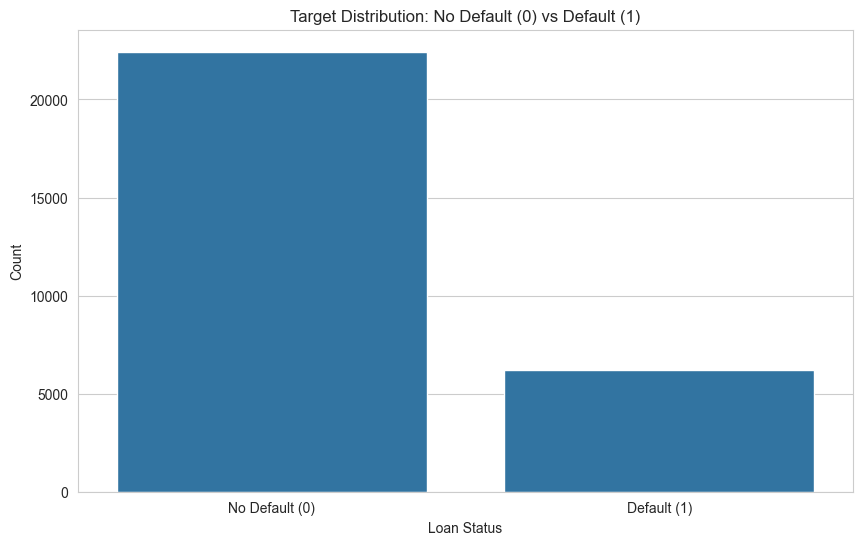

In [10]:
print(df['loan_status'].value_counts())
print(df['loan_status'].value_counts(normalize=True).round(3))

# Visualize target distribution
sns.countplot(data=df, x='loan_status')
plt.title('Target Distribution: No Default (0) vs Default (1)')
plt.xticks([0, 1], ['No Default (0)', 'Default (1)'])
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

## 5. Numerical Feature Distributions

Histograms show the overall shape of each numerical feature. Box plots stratified by `loan_status` highlight which features differ most between defaulters and non-defaulters.

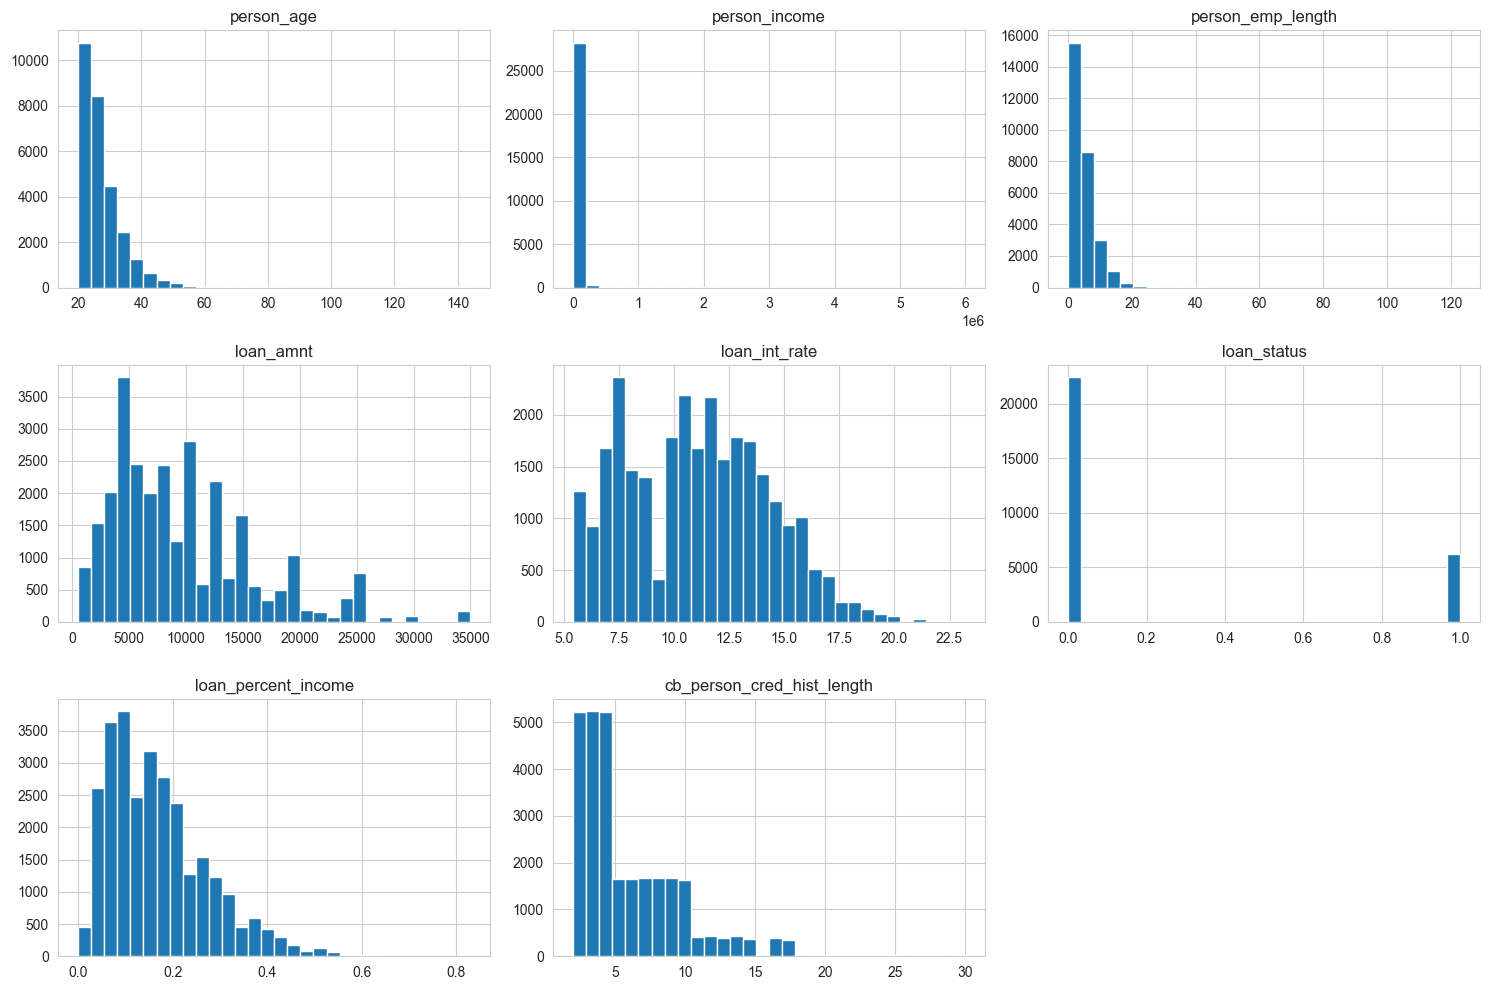

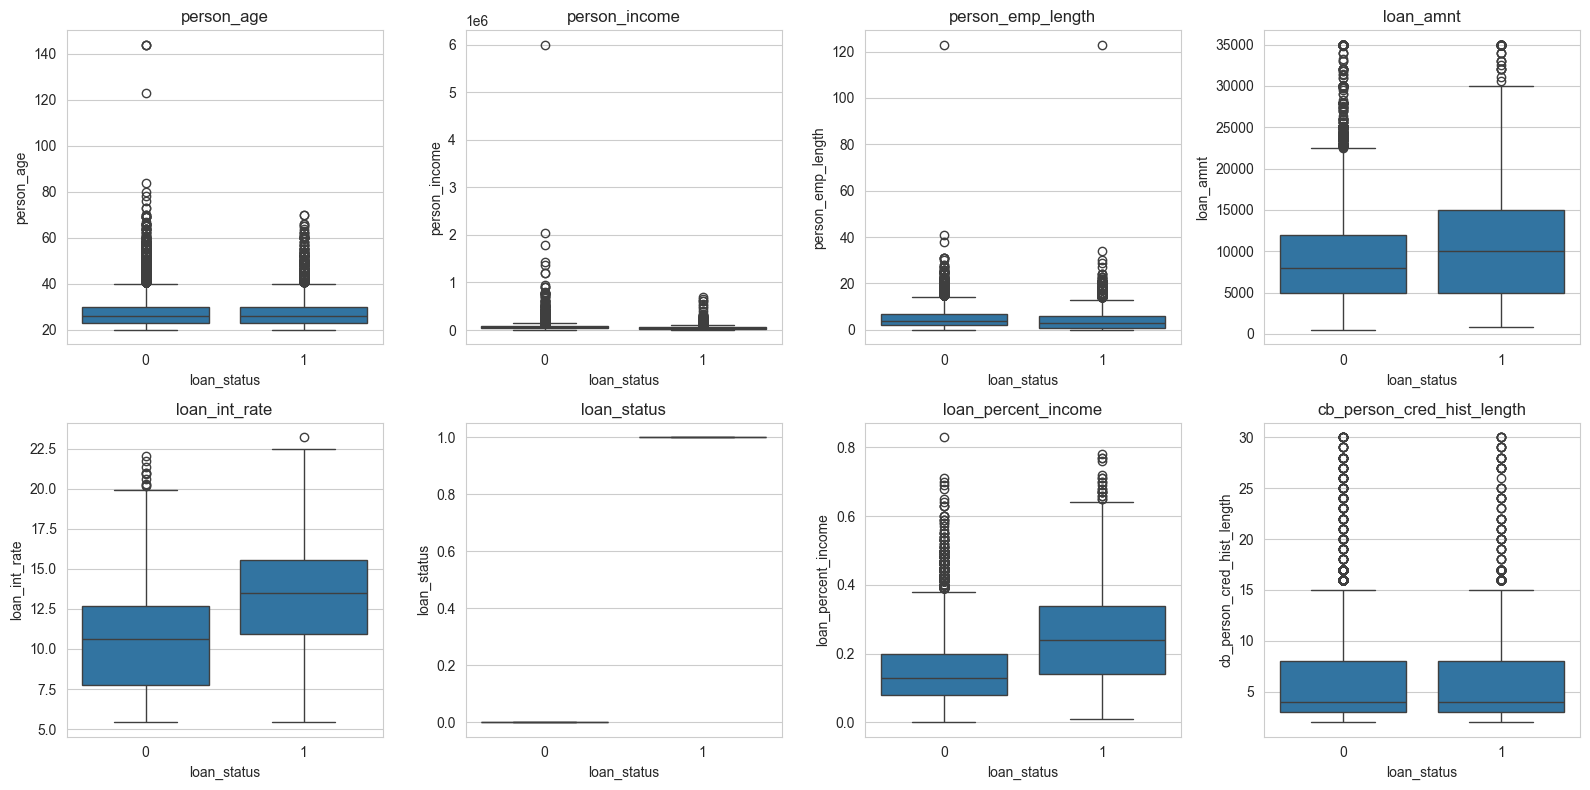

In [11]:
numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']

# Histograms
df[numerical_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Boxplot by target
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(numerical_cols):
    ax = axes[i//4, i%4]
    sns.boxplot(data=df, x='loan_status', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 6. Outlier Analysis

The `person_age` column contains unrealistic values such as 140 and 144. These are almost certainly data entry errors — no human can be 140 years old. Similarly, `person_emp_length` reaches 123 years, which is biologically impossible. Both columns need to be capped or the offending rows removed before modeling.

In [12]:
# Outlier detection — person_age and person_emp_length are most concerning
print(f"person_age max: {df['person_age'].max()} (suspicious — exceeds human lifespan)")
print(f"person_emp_length max: {df['person_emp_length'].max()} (cannot exceed the person's age)")
print(f"person_income max: {df['person_income'].max():,}")

# Age must always be greater than employment length — count impossible rows
anomaly = df[df['person_emp_length'] >= df['person_age']]
print(f"\nRows where emp_length >= age: {len(anomaly)}")

# Count rows with unrealistically high ages
print(f"Rows with age > 100: {(df['person_age'] > 100).sum()}")

person_age max: 144 (suspicious — exceeds human lifespan)
person_emp_length max: 123.0 (cannot exceed the person's age)
person_income max: 6,000,000

Rows where emp_length >= age: 2
Rows with age > 100: 4


## 7. Categorical Feature Analysis

Count plots split by `loan_status` reveal how each categorical feature relates to default risk. Look for categories with a noticeably higher share of defaults (1).

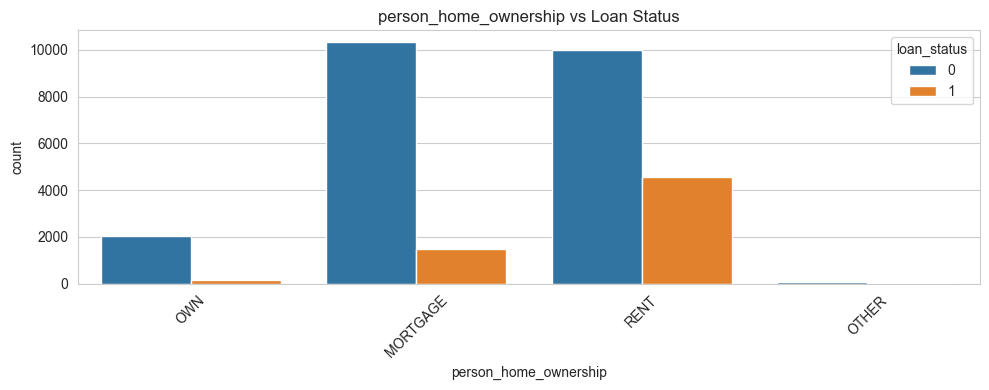

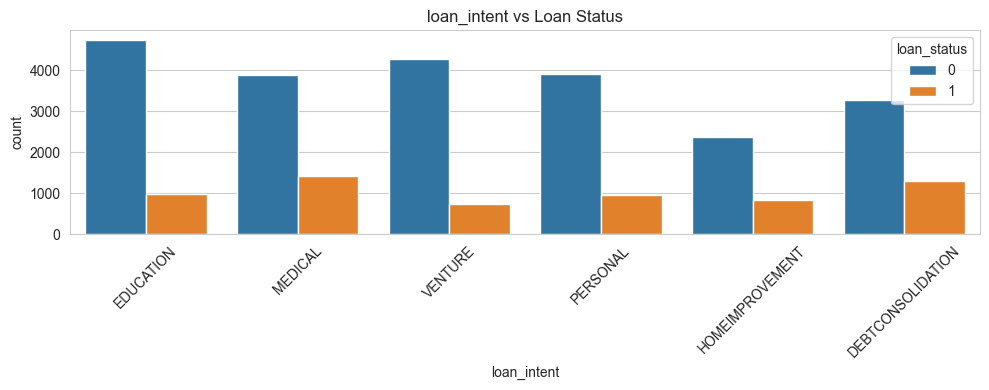

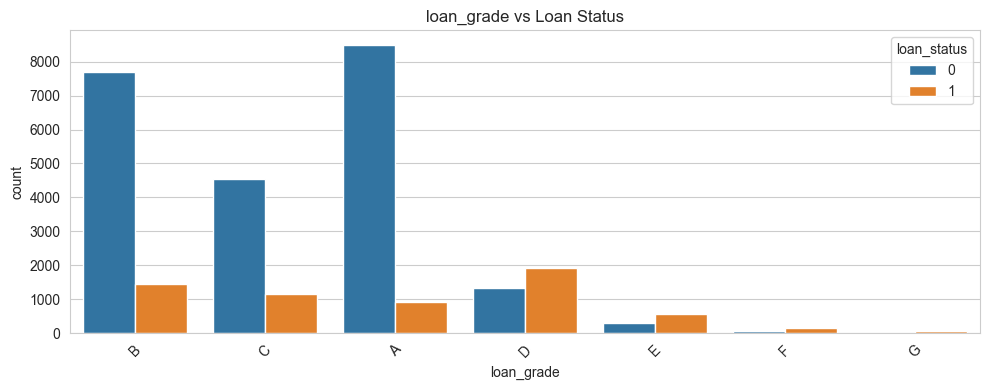

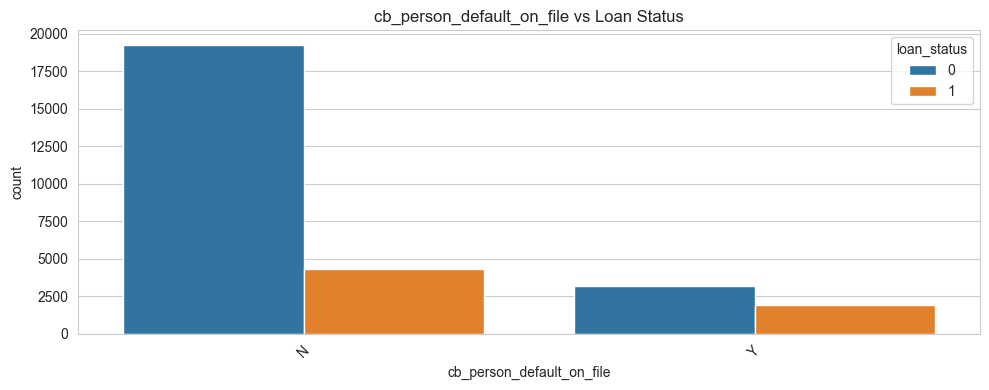

In [14]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, hue='loan_status')
    plt.title(f'{col} vs Loan Status')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 8. Correlation Analysis

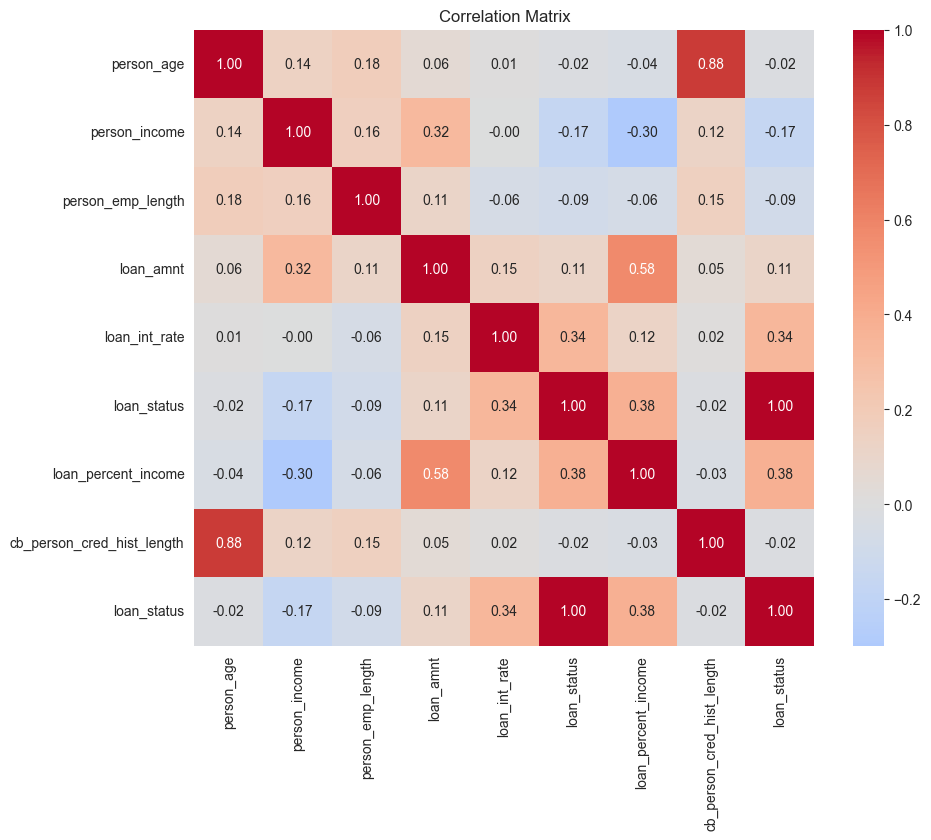

In [15]:
# Correlation matrix — numerical features only
plt.figure(figsize=(10, 8))
correlation = df[numerical_cols + ['loan_status']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Key Insights from EDA

1. **Class imbalance:** ~78% no-default (0) vs ~22% default (1). Address with `class_weight='balanced'` or SMOTE during the modeling phase.

2. **Strongest predictors (visual inspection):**
   - `loan_int_rate`: defaulters cluster at higher interest rates (grades D–G)
   - `loan_percent_income`: defaulters carry a noticeably higher debt-to-income ratio
   - `loan_grade`: grade A applicants rarely default; lower grades default at much higher rates
   - `cb_person_default_on_file`: prior default history is strongly associated with new default

3. **Outliers identified and removed:**
   - Rows with `person_age > 100` (data entry errors — values up to 144)
   - Rows where `person_emp_length >= person_age` (biologically impossible)

4. **Feature engineering opportunities:**
   - Ordinal encoding of `loan_grade` (A=1, …, G=7) preserves natural risk ordering
   - Bin `person_age` into life-stage groups (18–25, 26–35, 36–50, 50+)
   - Derive an interaction feature: `loan_amnt / person_income`

5. **Data quality:** After dropping ~12% of rows with missing values and removing outliers, the clean dataset is ready for preprocessing and modeling.

## 9. Next Steps

Based on the EDA findings, the preprocessing and modeling pipeline will:

1. **Encode categoricals:** ordinal encoding for `loan_grade` (A=1 … G=7); one-hot for `loan_intent` and `person_home_ownership`
2. **Scale numerics:** standardize `person_income`, `loan_amnt`, `loan_int_rate`, and `loan_percent_income`
3. **Handle class imbalance:** `class_weight='balanced'` in tree-based models, or SMOTE oversampling as an alternative
4. **Baseline → advanced models:** Logistic Regression → Random Forest → XGBoost / LightGBM
5. **Evaluation metrics:** ROC-AUC and macro F1-score given the class imbalance